# Body Fat % — Jackson-Pollock 3-Site (men: chest, abdomen, thigh)

Formulas:

- Sum of skinfolds: $S = \text{chest} + \text{abdomen} + \text{thigh}$ (mm)
- Body density (Jackson-Pollock 3-site, men):
  $$D = 1.10938 - 0.0008267\,S + 0.0000016\,S^2 - 0.0002574\,\text{age}$$
- Body fat (Siri): $\text{BF\%} = \frac{495}{D} - 450$

## Error sources modeled
1. **Random error** — between-trial variation across the 3 readings per site (cheap plastic caliper, slight position/pressure differences).
2. **Systematic error** — caliper bias $\pm 1$ mm applied consistently to *all* sites on a given day (a fixed offset, not random per-reading).
3. **Method/equation error** — Jackson-Pollock 3-site has a published SEE of about $\pm 3.5$ %BF vs. hydrostatic weighing. Shown as a separate band.

Errors 1+2 are propagated by Monte Carlo (10k draws per measurement day). Error 3 is added on top as a fixed band so you can see what the *equation itself* can't resolve.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

rng = np.random.default_rng(42)

CALIPER_SYSTEMATIC_MM = 1.0   # +/- 1 mm fixed bias (uniform between -1 and +1)
JP3_SEE_BF = 3.5              # Jackson-Pollock 3-site standard error of estimate (%BF)
N_MC = 10_000                 # Monte Carlo samples per measurement day

PLOTS_DIR = 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

In [2]:
def body_density(sum_mm, age):
    return 1.10938 - 0.0008267 * sum_mm + 0.0000016 * sum_mm**2 - 0.0002574 * age

def siri_bf(density):
    return 495.0 / density - 450.0

def bf_from_sites(chest, abdomen, thigh, age):
    return siri_bf(body_density(chest + abdomen + thigh, age))

In [3]:
df = pd.read_csv('measurements.csv', parse_dates=['timestamp']).sort_values('timestamp').reset_index(drop=True)
df.head()

,timestamp,age,chest1,chest2,chest3,abdomen1,abdomen2,abdomen3,thigh1,thigh2,thigh3
0,2026-04-02 19:00:00,33,24,26,25,43,42,41,26,30,32
1,2026-04-25 01:10:00,33,22,20,23,28,30,35,30,29,32
2,2026-04-25 22:22:00,33,24,20,22,32,33,32,26,30,33
3,2026-05-01 10:52:00,33,21,20,22,28,30,34,28,30,31
4,2026-05-04 15:58:00,33,18,22,23,30,36,33,28,27,30


In [4]:
def analyze_row(row, n=N_MC, sys_mm=CALIPER_SYSTEMATIC_MM):
    chest_obs = np.array([row.chest1, row.chest2, row.chest3], dtype=float)
    abd_obs   = np.array([row.abdomen1, row.abdomen2, row.abdomen3], dtype=float)
    thigh_obs = np.array([row.thigh1, row.thigh2, row.thigh3], dtype=float)
    age = float(row.age)

    def site_draws(obs):
        m = obs.mean()
        # Floor SE so 3 identical readings don't claim zero noise (~0.5 mm read precision).
        se = max(obs.std(ddof=1) / np.sqrt(len(obs)), 0.5 / np.sqrt(len(obs)))
        return rng.normal(m, se, size=n)

    c = site_draws(chest_obs)
    a = site_draws(abd_obs)
    t = site_draws(thigh_obs)

    # One systematic bias per draw, applied to all sites (fixed offset, not per-reading).
    bias = rng.uniform(-sys_mm, sys_mm, size=n)
    c += bias; a += bias; t += bias

    bf = bf_from_sites(c, a, t, age)

    return {
        'timestamp': row.timestamp,
        'sum_mm_mean': (chest_obs.mean() + abd_obs.mean() + thigh_obs.mean()),
        'bf_point': bf_from_sites(chest_obs.mean(), abd_obs.mean(), thigh_obs.mean(), age),
        'bf_mean': bf.mean(),
        'bf_std': bf.std(ddof=1),
        'bf_p2_5': np.percentile(bf, 2.5),
        'bf_p97_5': np.percentile(bf, 97.5),
    }

results = pd.DataFrame([analyze_row(r) for r in df.itertuples(index=False)])
results['hour'] = results['timestamp'].dt.hour
results['period'] = np.where(results['hour'] < 12, 'morning',
                      np.where(results['hour'] < 17, 'afternoon', 'evening'))
results

,timestamp,sum_mm_mean,bf_point,bf_mean,bf_std,bf_p2_5,bf_p97_5,hour,period
0,2026-04-02 19:00:00,96.333333,27.755321,27.759849,0.623840,26.528255,28.963842,19,evening
1,2026-04-25 01:10:00,83.000000,24.459646,24.453034,0.756927,22.989781,25.918758,1,morning
2,2026-04-25 22:22:00,84.000000,24.714227,24.705628,0.754055,23.247456,26.153988,22,evening
3,2026-05-01 10:52:00,81.333333,24.032722,24.037566,0.691116,22.694276,25.344925,10,morning
4,2026-05-04 15:58:00,82.333333,24.289268,24.297793,0.774323,22.792605,25.809284,15,afternoon
5,2026-05-10 12:20:00,80.000000,23.688834,23.688343,0.617393,22.504575,24.870991,12,afternoon
6,2026-05-17 11:03:00,79.666667,23.602537,23.600254,0.542759,22.577662,24.622504,11,morning
7,2026-05-24 11:51:00,83.000000,24.459646,24.448993,0.644173,23.197320,25.671708,11,morning
8,2026-06-01 09:30:00,85.666667,25.135893,25.129192,0.500252,24.220020,26.051802,9,morning
9,2026-06-07 11:12:00,78.666667,23.342870,23.337310,0.525570,22.369612,24.320088,11,morning


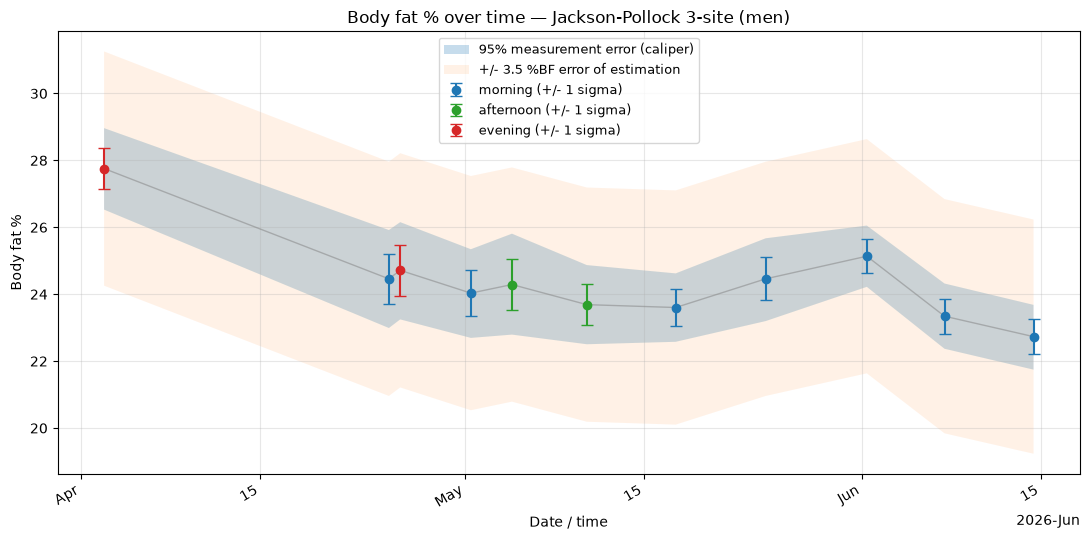

In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

x = results['timestamp']
y = results['bf_point']

# 95% measurement-error band (random + systematic, from Monte Carlo)
ax.fill_between(x, results['bf_p2_5'], results['bf_p97_5'],
                alpha=0.25, label='95% measurement error (caliper)')

# Equation/method error: JP3 SEE ~ +/- 3.5 %BF vs. hydrostatic
ax.fill_between(x, y - JP3_SEE_BF, y + JP3_SEE_BF,
                alpha=0.10, label=f'+/- {JP3_SEE_BF} %BF error of estimation')

ax.plot(x, y, '-', color='gray', alpha=0.5, linewidth=1, zorder=2)

period_colors = {'morning': '#1f77b4', 'afternoon': '#2ca02c', 'evening': '#d62728'}
for period, color in period_colors.items():
    sub = results[results['period'] == period]
    if len(sub):
        ax.errorbar(sub['timestamp'], sub['bf_point'], yerr=sub['bf_std'],
                    fmt='o', capsize=4, color=color, label=f'{period} (+/- 1 sigma)',
                    zorder=3)

ax.set_ylabel('Body fat %')
ax.set_xlabel('Date / time')
ax.set_title('Body fat % over time — Jackson-Pollock 3-site (men)')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=9)

locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'bodyfat_timeseries.png'), dpi=120, bbox_inches='tight')
plt.show()

## Rate of body fat change

Fit `BF% = a + b·t` weighted by each point's measurement uncertainty (`bf_std`).
The slope `b` is the rate of change. Reference rates from the literature:

- **Sustainable cut**: ~0.5 – 0.7 %BF / week (about 0.5 – 1 % bodyweight/week, of which ~70 – 80 % is fat).
- **Aggressive but viable** (short term, large deficit, novice, or higher starting BF): up to ~1 %BF / week.
- **Faster than that** sustained over many weeks usually means water/glycogen/muscle loss, or measurement drift — not pure fat loss.

Span:           72.6 days  (2026-04-02 → 2026-06-14)
First / last:   27.76%BF → 22.73%BF   (Δ = -5.02 %BF)

Fitted rate:    -0.0437 %BF / day   (SE 0.0087)
                -0.306 %BF / week  (SE 0.061, 95% CI [-0.426, -0.187])
                -1.312 %BF / month (SE 0.261)

Comparison:     within the SUSTAINABLE range (≤ 0.7 %BF/week). Looks healthy and likely mostly fat.


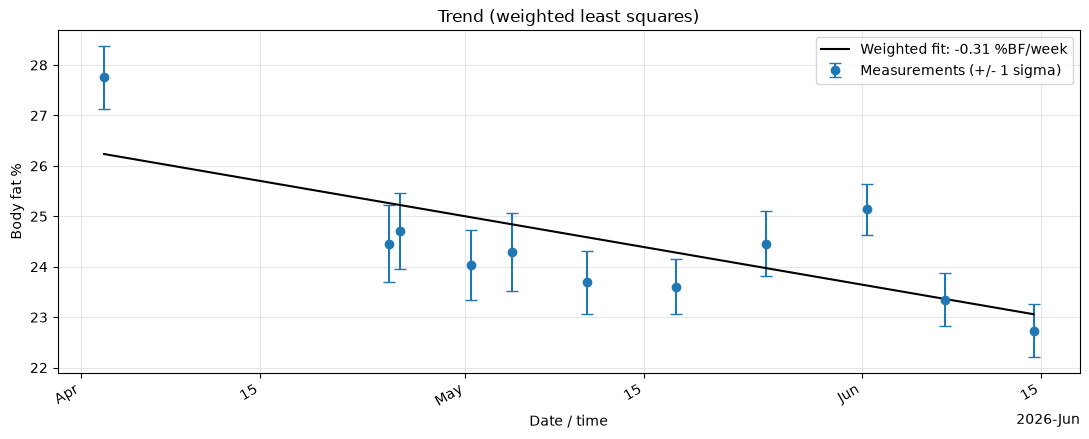

In [6]:
if len(results) < 2:
    print("Need at least 2 measurements to compute a rate.")
else:
    t_days = (results['timestamp'] - results['timestamp'].iloc[0]).dt.total_seconds().to_numpy() / 86400.0
    y = results['bf_point'].to_numpy()
    sigma = results['bf_std'].to_numpy()

    # Weighted least squares for slope (per day) and its standard error
    w = 1.0 / sigma**2
    W = w.sum()
    tw = (w * t_days).sum() / W
    yw = (w * y).sum() / W
    Stt = (w * (t_days - tw) ** 2).sum()
    slope = (w * (t_days - tw) * (y - yw)).sum() / Stt
    intercept = yw - slope * tw
    slope_se = np.sqrt(1.0 / Stt)  # standard error of slope (per day)

    span_days = t_days[-1] - t_days[0]
    total_change = y[-1] - y[0]

    rate_week = slope * 7
    rate_week_se = slope_se * 7
    rate_month = slope * 30
    rate_month_se = slope_se * 30

    print(f"Span:           {span_days:.1f} days  ({results['timestamp'].iloc[0].date()} → {results['timestamp'].iloc[-1].date()})")
    print(f"First / last:   {y[0]:.2f}%BF → {y[-1]:.2f}%BF   (Δ = {total_change:+.2f} %BF)")
    print()
    print(f"Fitted rate:    {slope:+.4f} %BF / day   (SE {slope_se:.4f})")
    print(f"                {rate_week:+.3f} %BF / week  (SE {rate_week_se:.3f}, 95% CI [{rate_week - 1.96*rate_week_se:+.3f}, {rate_week + 1.96*rate_week_se:+.3f}])")
    print(f"                {rate_month:+.3f} %BF / month (SE {rate_month_se:.3f})")
    print()

    # Compare to reference rates (signed: negative = loss)
    abs_week = abs(rate_week)
    if rate_week >= 0:
        verdict = "trend is flat or gaining — no fat-loss rate to compare."
    elif abs_week <= 0.7:
        verdict = "within the SUSTAINABLE range (≤ 0.7 %BF/week). Looks healthy and likely mostly fat."
    elif abs_week <= 1.0:
        verdict = "AGGRESSIVE but viable (0.7 – 1.0 %BF/week). Sustainable for a few weeks; watch for muscle loss / fatigue."
    else:
        verdict = ("FASTER THAN TYPICAL pure-fat loss (> 1 %BF/week). "
                   "Likely partly water/glycogen, or measurement drift. "
                   "Re-check after a couple more weeks before drawing conclusions.")
    print("Comparison:    ", verdict)

    # Quick plot of the trend line on top of the points
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.errorbar(results['timestamp'], y, yerr=sigma, fmt='o', capsize=4, label='Measurements (+/- 1 sigma)')
    t_line = np.linspace(t_days.min(), t_days.max(), 100)
    ax.plot(results['timestamp'].iloc[0] + pd.to_timedelta(t_line, unit='D'),
            intercept + slope * t_line, '-', color='black',
            label=f'Weighted fit: {rate_week:+.2f} %BF/week')
    ax.set_ylabel('Body fat %')
    ax.set_xlabel('Date / time')
    ax.set_title('Trend (weighted least squares)')
    ax.grid(True, alpha=0.3)
    ax.legend()
    locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

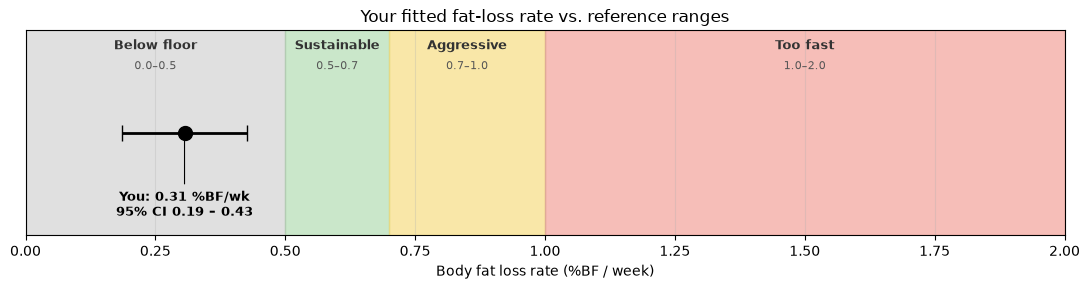

In [7]:
if len(results) >= 2:
    bands = [
        (0.0, 0.5, '#cccccc', 'Below floor'),
        (0.5, 0.7, '#a8d8a8', 'Sustainable'),
        (0.7, 1.0, '#f5d76e', 'Aggressive'),
        (1.0, 2.0, '#f1948a', 'Too fast'),
    ]

    loss_rate = -rate_week
    loss_se   = rate_week_se
    ci_lo     = max(0, loss_rate - 1.96 * loss_se)
    ci_hi     = loss_rate + 1.96 * loss_se
    x_max     = max(2.0, ci_hi + 0.2)

    fig, ax = plt.subplots(figsize=(11, 3.0))

    for lo, hi, color, label in bands:
        ax.axvspan(lo, hi, color=color, alpha=0.6)
        center = (lo + min(hi, x_max)) / 2
        if center < x_max:
            ax.text(center, 0.85, label, ha='center', va='center',
                    fontsize=9, fontweight='bold', color='#333')
            ax.text(center, 0.65, f'{lo:.1f}–{hi:.1f}', ha='center', va='center',
                    fontsize=8, color='#555')

    ax.errorbar([loss_rate], [0], xerr=[[loss_rate - ci_lo], [ci_hi - loss_rate]],
                fmt='o', color='black', capsize=6, markersize=10, linewidth=2, zorder=5)
    ax.annotate(f'You: {loss_rate:.2f} %BF/wk\n95% CI {ci_lo:.2f} – {ci_hi:.2f}',
                xy=(loss_rate, 0), xytext=(loss_rate, -0.7),
                ha='center', va='center', fontsize=9, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color='black', lw=0.8))

    ax.set_xlim(0, x_max)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.set_xlabel('Body fat loss rate (%BF / week)')
    ax.set_title('Your fitted fat-loss rate vs. reference ranges')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'rate_speedometer.png'), dpi=120, bbox_inches='tight')
    plt.show()

## Projection: time to reach target body fat %

Start from your **latest actual measurement** and carry the weighted-least-squares rate
(`slope`) forward to a configurable target. The estimate assumes the **current rate of fat
loss holds constant** — in practice loss usually slows as you lean out, so treat this as a
best-case linear projection.

- `TARGET_BF` — the goal body fat %, default **15%**.
- "Current" is the most recent measured BF%; the rate is the fitted slope.
- The date range comes from the slope's 95% CI.
- If the trend is flat or gaining (slope ≥ 0), the target is not reachable at the current rate.

Current (latest): 22.73 %BF   on 2026-06-14
Target:           15.00 %BF
Gap to close:     +7.73 %BF
Current rate:     -0.306 %BF / week

Estimated time:   177 days  (~25.3 weeks, ~5.8 months)
Estimated date:   2026-12-08
95% CI on date:   2026-10-19  …  2027-03-31


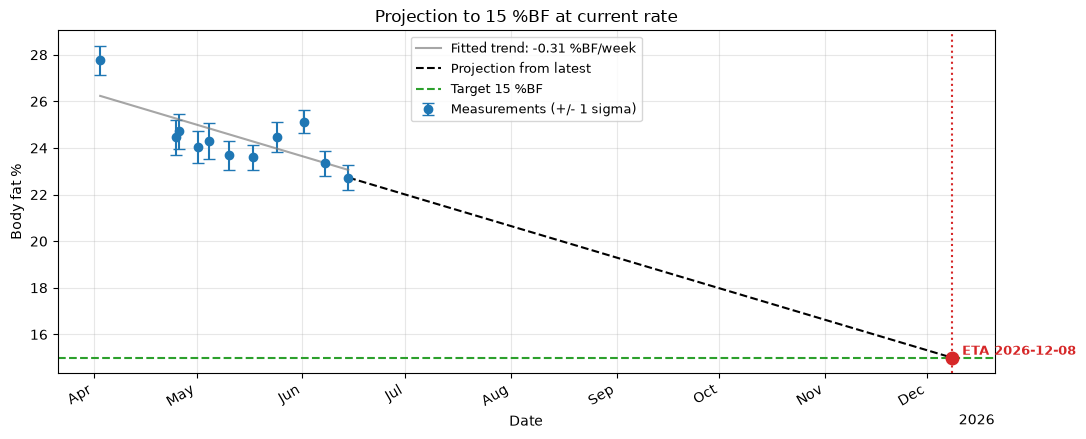

In [8]:
TARGET_BF = 15.0   # goal body fat % — change this to project to a different target

if len(results) < 2:
    print("Need at least 2 measurements to project a time-to-target.")
else:
    # Anchor on the most recent ACTUAL measurement, then carry the fitted rate forward.
    last_t    = t_days[-1]
    last_date = results['timestamp'].iloc[-1]
    bf_now    = y[-1]                      # latest measured body fat %

    print(f"Current (latest): {bf_now:.2f} %BF   on {last_date.date()}")
    print(f"Target:           {TARGET_BF:.2f} %BF")
    print(f"Gap to close:     {bf_now - TARGET_BF:+.2f} %BF")
    print(f"Current rate:     {rate_week:+.3f} %BF / week")
    print()

    if TARGET_BF >= bf_now:
        print(f"Already at or below the target ({bf_now:.2f} ≤ {TARGET_BF:.2f} %BF). Nothing to project.")
        eta_date = None
    elif slope >= 0:
        print("Trend is flat or gaining (slope ≥ 0) — the target is NOT reachable at the current rate.")
        eta_date = None
    else:
        # Days from the latest measurement until the rate carries you down to TARGET_BF.
        days_to_target = (TARGET_BF - bf_now) / slope          # slope < 0, numerator < 0 => positive
        eta_date = last_date + pd.to_timedelta(days_to_target, unit='D')

        # Date range from the slope's 95% CI (steeper loss => sooner, shallower => later).
        slope_lo = slope - 1.96 * slope_se   # most negative (fastest)
        slope_hi = slope + 1.96 * slope_se   # least negative (slowest)
        eta_fast = eta_slow = None
        if slope_lo < 0:
            eta_fast = last_date + pd.to_timedelta((TARGET_BF - bf_now) / slope_lo, unit='D')
        if slope_hi < 0:
            eta_slow = last_date + pd.to_timedelta((TARGET_BF - bf_now) / slope_hi, unit='D')

        weeks = days_to_target / 7.0
        print(f"Estimated time:   {days_to_target:.0f} days  (~{weeks:.1f} weeks, ~{days_to_target/30.44:.1f} months)")
        print(f"Estimated date:   {eta_date.date()}")
        if eta_fast is not None and eta_slow is not None:
            print(f"95% CI on date:   {eta_fast.date()}  …  {eta_slow.date()}")
        elif eta_fast is not None:
            print(f"95% CI on date:   {eta_fast.date()}  …  (slowest bound: rate may stall, no finite ETA)")
        else:
            print("95% CI on date:   slope CI includes ≥ 0 — upper bound on time is unbounded.")

    # Plot: measurements, the fitted trend over the data span, and the projection
    # from the latest point forward to the target.
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.errorbar(results['timestamp'], y, yerr=sigma, fmt='o', capsize=4,
                label='Measurements (+/- 1 sigma)')

    # Fitted trend across the measured span (reference).
    t_fit = np.linspace(t_days.min(), t_days.max(), 100)
    ax.plot(results['timestamp'].iloc[0] + pd.to_timedelta(t_fit, unit='D'),
            intercept + slope * t_fit, '-', color='gray', alpha=0.7,
            label=f'Fitted trend: {rate_week:+.2f} %BF/week')

    # Projection from the latest actual point, using the fitted slope.
    if eta_date is not None:
        t_proj = np.linspace(last_t, last_t + days_to_target, 100)
        ax.plot(results['timestamp'].iloc[0] + pd.to_timedelta(t_proj, unit='D'),
                bf_now + slope * (t_proj - last_t), '--', color='black',
                label='Projection from latest')

    ax.axhline(TARGET_BF, color='#2ca02c', linestyle='--', linewidth=1.5,
               label=f'Target {TARGET_BF:.0f} %BF')
    if eta_date is not None:
        ax.axvline(eta_date, color='#d62728', linestyle=':', linewidth=1.5)
        ax.plot([eta_date], [TARGET_BF], 'o', color='#d62728', markersize=9, zorder=5)
        ax.annotate(f'  ETA {eta_date.date()}', xy=(eta_date, TARGET_BF),
                    color='#d62728', fontweight='bold', va='bottom', fontsize=9)

    ax.set_ylabel('Body fat %')
    ax.set_xlabel('Date')
    ax.set_title(f'Projection to {TARGET_BF:.0f} %BF at current rate')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=9)
    locator = mdates.AutoDateLocator(minticks=4, maxticks=10)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, 'projection_to_target.png'), dpi=120, bbox_inches='tight')
    plt.show()

## How to add new measurements

Append rows to `measurements.csv` (one row per measurement session) and re-run. Columns:

`timestamp, age, chest1, chest2, chest3, abdomen1, abdomen2, abdomen3, thigh1, thigh2, thigh3`

`timestamp` accepts any pandas-parseable datetime (e.g. `2026-05-01 07:30`). Multiple measurements per day are supported — they plot as separate points and are color-coded morning / afternoon / evening. All skinfolds in mm. Men's JP3 formula; ask if you need the women's variant.